# Credit Risk Exposures

## Basic Toy Model (with Interest Rate Swaps)

In [1]:
import numpy as np

def rate_models(r0, kappa, theta, sigma, T, dt, num_simulations, model_type, seed = 1000):

    rng = np.random.default_rng(seed=seed)
    n_steps = int(T/dt)
    rates = np.zeros((num_simulations, n_steps))
    rates[:,0] = r0

    if model_type == 'Vasicek':
        for t in range(1, n_steps):
            dW = rng.standard_normal(size=num_simulations)
            rates[:, t] = rates[:, t-1] + kappa * (theta - rates[:, t-1]) * dt + sigma * np.sqrt(dt) * dW
    
    elif model_type == 'Hull-White':
        exp_kdt = np.exp(-kappa * dt)
        sigma_terms = sigma * np.sqrt((1 - np.exp(-2 * kappa * dt))/(2 * kappa))
        for t in range(1, n_steps):
            z = rng.standard_normal(size=num_simulations)
            rates[:,t] = rates[:, t-1] * exp_kdt + theta * (1 - exp_kdt) + sigma_terms * z
    else:
        print(f"Please insert correct model type as 'Vasicek' or 'Hull-White'....")
    
    return rates

def swap_exposures(rates, fixed_rate= 0.02, notional = 1_000_000):
    mtm = (rates - fixed_rate) * notional
    return mtm

def ccr_metrics(exp, q=0.99):
    ee = np.mean(exp, axis=0)
    epe = np.mean(np.maximum(exp, 0), axis=0)
    pfe = np.quantile(np.maximum(exp, 0), q, axis=0)
    return ee, epe, pfe


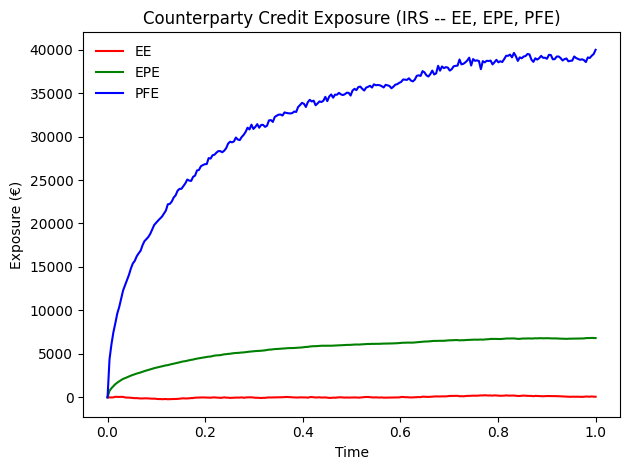

In [37]:
import numpy as np
import matplotlib.pyplot as plt

r0 = 0.02
kappa = 1.5
theta = .02
sigma = 0.03
T = 1
dt = 1/252
num_simulations = 10_000

# Calculations
rates = rate_models(
    r0=r0, 
    kappa=kappa, 
    theta=theta, 
    sigma=sigma, 
    T=T, 
    dt=dt, 
    num_simulations=num_simulations, 
    model_type='Hull-White',
    seed=10000
    )

exposure_paths = swap_exposures(rates=rates)
ee, epe, pfe = ccr_metrics(exp=exposure_paths)

# Plotting the results
time_grid = np.linspace(0, T, exposure_paths.shape[1])
plt.plot(time_grid, ee, color = 'r', label = 'EE')
plt.plot(time_grid, epe, color = 'g', label = 'EPE')
plt.plot(time_grid, pfe, color = 'b', label = 'PFE')
plt.legend(frameon = False)
plt.title('Counterparty Credit Exposure (IRS -- EE, EPE, PFE)')
plt.xlabel('Time')
plt.ylabel('Exposure (€)')
plt.tight_layout()
plt.show()


## Multiple Asset Portfolio

* Steps to Add
    - Risk Factor simulation
        - Interest rates (HW/LMM/Vasicek)
        - FX (GBM)
        - Equity (GBM/Heston)
        - Credit Spread (Hazard rate)
    - Portfolio Valuation
        - Reprice trades under each scenarios
    - Exposure engine
        - Exposure = max(mtm, 0)
    - Aggregation & Risk Metrics
        - EE, EPE, PFE
        - CVA, DVA, FVA

In [10]:
# Multi-Asset Modeling
import numpy as np

# step 1
def generate_correlated_normals(num_simulations, cor_matrix, seed=1000):
    rng = np.random.default_rng(seed=seed)
    L = np.linalg.cholesky(cor_matrix)
    z = rng.normal(size=(num_simulations, cor_matrix.shape[0]))
    return z@L.T

# Step 2
def simulate_markets(r0, s0_fx, s0_eq, kappa, theta, sigma_r, sigma_fx, sigma_eq, cor_matrix, T, dt, num_simulations, seed = 11000):
    rng = np.random.default_rng(seed=seed)
    n_steps = int(T/dt) + 1

    rates = np.zeros((num_simulations, n_steps))
    fx = np.zeros((num_simulations, n_steps))
    equity = np.zeros((num_simulations, n_steps))

    rates[:, 0] = r0
    fx[:, 0] = s0_fx
    equity[:, 0] = s0_eq

    # Hull-White
    exp_kdt = np.exp(-kappa * dt)
    vol_r = sigma_r * np.sqrt((1-np.exp(-2*kappa*dt))/(2*kappa))

    for t in range(1, n_steps):
        shocks = generate_correlated_normals(num_simulations=num_simulations, cor_matrix=cor_matrix, seed=seed)

        z_r = shocks[:, 0]
        z_fx = shocks[:, 1]
        z_eq = shocks[:, 2]

        rates[:, t] = (rates[:,t-1] * exp_kdt + theta * (1 - exp_kdt) + vol_r * z_r)
        fx[:, t] = fx[:,t-1] * np.exp(-0.5 * sigma_fx**2 * dt + sigma_fx * np.sqrt(dt) * z_fx)
        equity[:, t] = equity[:, t-1] * np.exp(-0.5 * sigma_eq**2 * dt + sigma_eq * np.sqrt(dt) * z_eq)

        return rates, fx, equity

# Step 3
def portfolio_valuation(rates, fx, equity, swap_rate = 0.02, fx_strike = 1.00, eq_strike = 100, notional = 10_000):
    swap = notional * (rates - swap_rate) # irs swaps
    fx_trade = notional * (fx - fx_strike) # fx forward
    eq_trade = notional * np.maximum(equity - eq_strike, 0) # call equity

    portfolio_value = swap + fx_trade + eq_trade

    return portfolio_value

# Step 4
def ccr_metrics(exp, q=0.99):
    ee = np.mean(exp, axis=0)
    epe = np.mean(np.maximum(exp,0), axis=0)
    pfe = np.quantile(np.maximum(exp,0), q, axis=0)
    return ee, epe, pfe


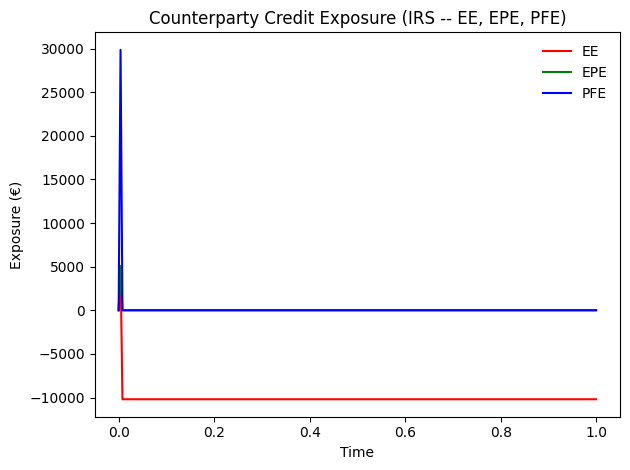

In [15]:
import matplotlib.pyplot as plt

r0 = 0.02
s0_fx = 1.0
s0_eq = 100

kappa = 1.56
theta = 0.20

sigma_r = 0.0145
sigma_fx = 0.12
sigma_eq = 0.20

cor_matrix = np.array([
    [1.0, -0.30, 0.20],
    [-0.30, 1.0, 0.40],
    [0.20, 0.40, 1.0],
])

T = 1
dt = 1 / 252
num_simulations = 50_000

rates, fx, equity = simulate_markets(r0=r0, s0_fx=s0_fx, s0_eq=s0_eq, kappa=kappa, theta=theta, sigma_r=sigma_r, sigma_fx=sigma_fx, sigma_eq=sigma_eq, cor_matrix=cor_matrix, T=T, dt=dt, num_simulations=num_simulations)
exposure_paths = portfolio_valuation(rates=rates, fx=fx, equity=equity)
ee, epe, pfe = ccr_metrics(exp=exposure_paths)

time_grid = np.linspace(0, T, exposure_paths.shape[1])
plt.plot(time_grid, ee, color = 'r', label = 'EE')
plt.plot(time_grid, epe, color = 'g', label = 'EPE')
plt.plot(time_grid, pfe, color = 'b', label = 'PFE')
plt.legend(frameon = False)
plt.title('Counterparty Credit Exposure (IRS -- EE, EPE, PFE)')
plt.xlabel('Time')
plt.ylabel('Exposure (€)')
plt.tight_layout()
plt.show()